Для работы были выбраны данные по стоимости жилья в России с 2018 по 2021 года. https://www.kaggle.com/datasets/mrdaniilak/russia-real-estate-20182021

# Импорт библиотек

In [98]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import os
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.utils import resample
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Загрузка DataFrame

In [2]:
# Download latest version
path = kagglehub.dataset_download("mrdaniilak/russia-real-estate-20182021")

print("Path to dataset files:", path)

src = os.path.join(path, os.listdir(path)[0])  # путь к CSV внутри папки
dst = 'russia_real_estate.csv'  # сохранит рядом с ноутбуком

shutil.copy(src, dst)

df = pd.read_csv('russia_real_estate.csv')

Path to dataset files: C:\Users\bogd\.cache\kagglehub\datasets\mrdaniilak\russia-real-estate-20182021\versions\3


# Вывод таблицы

In [3]:
# Посмотрим первые 5 строк загруженного датафрейма
df.head()

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1


# Описание значений таблицы

In [4]:
df.describe()

,price,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
count,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06
mean,4.422029e+06,5.403826e+01,5.324433e+01,4.307141e+03,1.948966e+00,6.214530e+00,1.139892e+01,1.726173e+00,5.391825e+01,1.062840e+01,3.945399e+00
std,2.150752e+07,4.622758e+00,2.074763e+01,3.308050e+03,1.038537e+00,4.957419e+00,6.535734e+00,1.082133e+00,3.335293e+01,9.792380e+00,4.558357e+00
min,-2.144967e+09,4.145906e+01,1.989020e+01,3.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-2.000000e+00,7.000000e-02,1.000000e-02,1.000000e+00
25%,1.950000e+06,5.337768e+01,3.777790e+01,2.661000e+03,1.000000e+00,2.000000e+00,5.000000e+00,1.000000e+00,3.800000e+01,7.000000e+00,1.000000e+00
50%,2.990000e+06,5.517139e+01,4.306774e+01,2.922000e+03,2.000000e+00,5.000000e+00,1.000000e+01,2.000000e+00,4.802000e+01,9.700000e+00,1.000000e+00
75%,4.802000e+06,5.622613e+01,6.564895e+01,6.171000e+03,3.000000e+00,9.000000e+00,1.600000e+01,2.000000e+00,6.313000e+01,1.270000e+01,1.100000e+01
max,2.147484e+09,7.198040e+01,1.625361e+02,6.188800e+04,5.000000e+00,3.900000e+01,3.900000e+01,1.000000e+01,7.856000e+03,9.999000e+03,1.100000e+01


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 13 columns):
 #   Column         Dtype  
---  ------         -----  
 0   price          int64  
 1   date           str    
 2   time           str    
 3   geo_lat        float64
 4   geo_lon        float64
 5   region         int64  
 6   building_type  int64  
 7   level          int64  
 8   levels         int64  
 9   rooms          int64  
 10  area           float64
 11  kitchen_area   float64
 12  object_type    int64  
dtypes: float64(4), int64(7), str(2)
memory usage: 543.2 MB


В процессе анализа удалось определить, что в данных есть некоторые "выбросы":
1. min area = 7.000000e-02 - квартира площадью 7 квадратных сантиметров
2. max area = 7.856000e+03 - квартира площадью 7856 квадратных метров
3. rooms = -2 - квартира с -2 комнатами
4. kitchen_area min = 0.01, max =  9999, такие же выбросы как с площадью квартир

# Поиск пропущенных значений

Не смотря на то что count для каждого параметра равен, можно предположить что Nan значений нет, но все же стоит проверить есть ли такие значения.

In [6]:
df[df.isnull() == True].count()

price            0
date             0
time             0
geo_lat          0
geo_lon          0
region           0
building_type    0
level            0
levels           0
rooms            0
area             0
kitchen_area     0
object_type      0
dtype: int64

Отлично, пропущенные данные отсуствуют.

# Поиск дубликатов

In [7]:
duplicates = df[df.duplicated()]

In [8]:
duplicates

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
10966,1200000,2018-09-10,06:28:40,55.012935,83.004523,9654,1,2,10,1,39.35,6.00,11
25141,8213280,2018-09-11,20:40:19,59.756070,30.365931,2661,2,3,4,3,96.40,13.00,11
42858,3960000,2018-09-14,08:36:58,55.961723,37.650433,81,2,6,6,3,69.80,9.40,11
42860,2900000,2018-09-14,08:36:58,55.961723,37.650433,81,2,1,6,2,50.30,11.20,11
45455,1718665,2018-09-14,14:19:50,55.009805,82.904909,9654,3,2,26,1,29.40,5.00,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399412,3250000,2021-04-26,07:21:26,55.043192,82.981253,9654,1,16,17,1,36.50,8.20,11
5409949,2055275,2021-04-27,02:25:34,56.858606,35.911676,2880,1,5,17,1,35.57,10.12,11
5413127,3400000,2021-04-27,06:00:24,54.512081,36.233588,2328,3,11,12,2,45.30,8.00,1
5448742,4610000,2021-04-30,06:48:38,55.975702,37.100761,81,1,1,17,1,48.00,12.00,11


Как видно - дубликаты есть, учиытвая что в датасете - цены на недвижимость необходим для корректности эти дубликаты удалить, оставляя последнее вхождение - keep='last'

In [9]:
df = df.drop_duplicates(keep='last')

# Поиск выбросов -  обработка

В процессе анализа удалось узнать, что в данных есть выбросы и ошибки, проанализируем их. 

*Rooms*

In [10]:
df['rooms'].value_counts()

rooms
 1     2066340
 2     1827056
 3     1097100
-1      306111
 4      152121
 5       22575
 6        2357
 7         788
 8         353
-2         343
 9         338
 10          1
Name: count, dtype: int64

Есть странные значения:
* -1: 306209
* -2: 343

*area и kichen_area*

Заглянув в описание датасета удалось узнать: rooms - the number of living rooms. If the value is "-1", then it means "studio apartment". Соотвественно кол-во комнат '-1' - студии, а не физически невозможные данные. В свою очередь значение '-2' - смело можно отнести к "мусору" и удалить (либо заменить на Nan)

In [11]:
df['area'].quantile([0.001, 0.01, 0.99, 0.999])

0.001      6.8
0.010     19.8
0.990    138.2
0.999    294.0
Name: area, dtype: float64

Перцентиль 0.1% = 6.8 м² — все же странные данные. Есть объекты и меньше. Также не стоит забывать про min area 0.07m.
Перцентиль 99.9% = 294 м² — вполне реалистично для больших квартир или пентхаусов, при max = 7856 — верхний хвост тоже нужно обрезать.

In [12]:
df['kitchen_area'].quantile([0.001, 0.01, 0.99, 0.999])

0.001     1.0
0.010     2.0
0.990    30.5
0.999    55.0
Name: kitchen_area, dtype: float64

In [13]:
df['price'].quantile([0.001, 0.1, 0.99, 0.999])

0.001      200000.0
0.100     1390000.0
0.990    24100000.0
0.999    87000000.0
Name: price, dtype: float64

Проведем логическую проверку. Возможно в данных есть некотоые ошибки, например, kitchen_area > area, level > levels. Ведь площадь кухни не может быть больше площади объекта в целом, а также этаж квартиры не может быть больше количества этажей в здании в целом.

In [14]:
len(df[df['kitchen_area'] > df['area']])

3266

In [15]:
len(df[df['level'] > df['levels']])

1072

Логические нарушения:

kitchen_area > area — 3266 строк. Физически невозможно.
level > levels — 1072 строки. Этаж квартиры выше, чем этажей в доме — тоже невозможно.

kitchen_area:

0.1% = 1 м², 1% = 2 м² — кухня в 1–2 м² нереалистична. А max = 9999 — тоже явная ошибка.

price:

0.1% = 200K руб. — для регионов возможно (комната), но ниже — маловероятно, даже на момент 2018 года.
99.9% = 87M руб. — реалистично для элитной недвижимости. А вот min = −2.14B и max = 2.14B — это границы int32, просто артефакты, которые необходимо удалить.

## Обработка нереалистичных данных / выбросов

### Очистка данных

#### Этап 1: Удаление невалидных данных 

На основе анализа `describe()` и предметной области выявлены следующие проблемы:

| Проблема | Колонка | Условие | Кол-во строк |
|----------|---------|---------|--------------|
| Переполнение int32 | price | price ≤ 0 или price ≥ 2 147 483 647 | ? |
| Невалидное значение | rooms | rooms = -2 | 343 |
| Логическое нарушение | kitchen_area, area | kitchen_area > area | 3 266 |
| Логическое нарушение | level, levels | level > levels | 1 072 |

Эти записи не подлежат восстановлению и будут удалены.

Удалим невалидные строки

In [16]:
df.drop(df[df['price'] <= 0].index, inplace = True)

In [17]:
df.drop(df[df['rooms'] == -2].index, inplace = True)

In [18]:
df.drop(df[df['kitchen_area'] > df['area']].index, inplace = True)

In [19]:
df.drop(df[df['level'] > df['levels']].index, inplace = True)

In [20]:
df.shape

(5470541, 13)

Для удаления использую следующую логику: вычислю границы при помощи метода quantile, а далее отфильтрую при помощи between.

In [21]:
# Создаем маски для дальнейшей фильтрации 
low_area = df['area'].quantile(0.005)
high_area = df['area'].quantile(0.995)
area_mask = df['area'].between(low_area, high_area)

low_price = df['price'].quantile(0.005)
high_price = df['price'].quantile(0.995)
price_mask = df['price'].between(low_price, high_price)

low_kitchen_area = df['kitchen_area'].quantile(0.005)
high_kitchen_area = df['kitchen_area'].quantile(0.995)
kitchen_area_mask = df['kitchen_area'].between(low_kitchen_area, high_kitchen_area)

In [22]:
    # Применим получившиеся маски
df = df[area_mask & price_mask & kitchen_area_mask]

In [23]:
df.shape

(5338839, 13)

#### Этап 2: Перекодирование

- **rooms**: значение `-1` (студии) перекодируется в `0` для корректной работы моделей
- **date** и **time**: объединение в единый datetime-признак

In [24]:
df['rooms'] = df['rooms'].replace(-1, 0)

In [25]:
df

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5477001,19739760,2021-05-01,20:13:58,55.804736,37.750898,3,1,8,17,4,93.2,13.8,11
5477002,12503160,2021-05-01,20:14:01,55.841415,37.489624,3,2,17,32,2,45.9,6.6,11
5477003,8800000,2021-05-01,20:14:04,56.283909,44.075408,2871,2,4,17,3,86.5,11.8,1
5477004,11831910,2021-05-01,20:14:12,55.804736,37.750898,3,1,8,33,2,52.1,18.9,11


In [26]:
# Объеденим date и time в datetime, так легче будет работать с этими данными
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])

Теперь можно удалить столбцы date и time

In [27]:
df = df.drop(columns = ['date', 'time'])

### Проверим дубликаты

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.drop_duplicates(inplace=True)

# Свойства таблицы после обработки 

| Этап | Строк до | Строк после | Удалено |
|------|----------|-------------|---------|
| Исходные данные | 5 477 006 | — | — |
| Удаление невалидных | 5 477 006 | 5 472 064 | 4 942 |
| Фильтрация выбросов | 5 472 064 | 5 340 309 | 131 755 |
| Перекодирование rooms | — | — | 0 |
| Удаление дубликатов | 5 340 309 | 5 338 793 | 1 516 |

# Выявление коррелирующих признаков

### Корреляционная матрица (числовые признаки)

Используем коэффициент Spearman, так как распределения цен 
и площадей скошены, а зависимости между признаками 
не обязательно линейны.

In [30]:
numeric_cols = ['price', 'area', 'kitchen_area', 'level', 'levels', 'rooms']

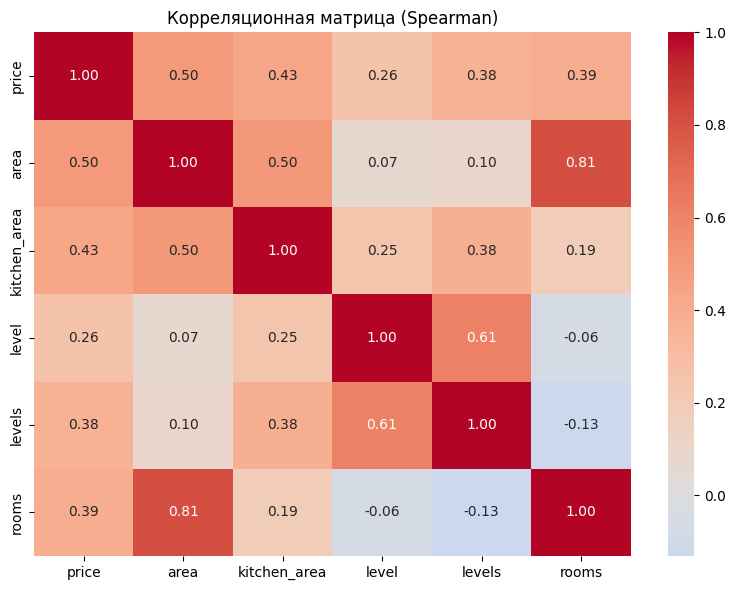

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_cols].corr(method='spearman'),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    center=0
)
plt.title('Корреляционная матрица (Spearman)')
plt.tight_layout()
plt.show()

### Анализ категориальных признаков

Для признаков building_type и object_type корреляция Spearman неприменима, 
так как это номинальные данные. Вместо этого анализируем распределение цены 
по категориям через boxplot.

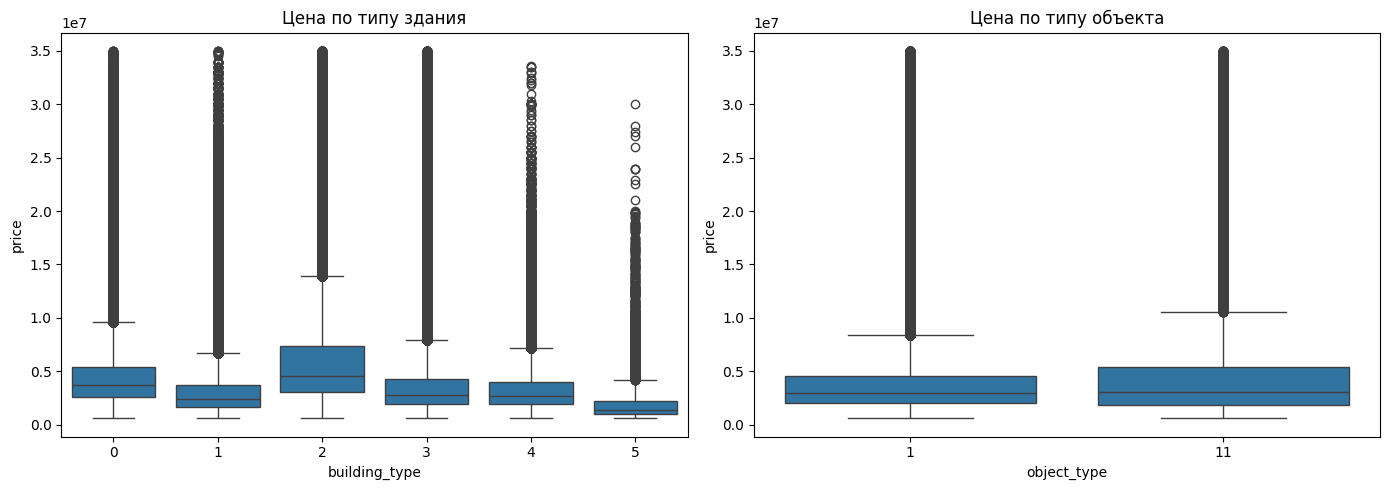

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='building_type', y='price', ax=axes[0])
axes[0].set_title('Цена по типу здания')

sns.boxplot(data=df, x='object_type', y='price', ax=axes[1])
axes[1].set_title('Цена по типу объекта')

plt.tight_layout()
plt.show()

In [33]:
df.groupby('building_type')['price'].median().sort_values(ascending=False)

building_type
2    4557474.0
0    3700000.0
3    2800000.0
4    2700000.0
1    2400000.0
5    1399900.0
Name: price, dtype: float64

In [34]:
df.groupby('object_type')['price'].median().sort_values(ascending=False)

object_type
11    3090000.0
1     2950000.0
Name: price, dtype: float64

### Выводы по категориальным признакам

**building_type** — существенное влияние на цену:
- Самый дорогой: тип 2 (медиана 4.56M руб.)
- Самый дешёвый: тип 5 (медиана 1.40M руб.)
- Разброс медиан ~3x — признак значим для модели

**object_type** — слабое влияние:
- Тип 1: медиана 2.95M руб.
- Тип 11: медиана 3.09M руб.
- Разница ~5% — признак малоинформативен

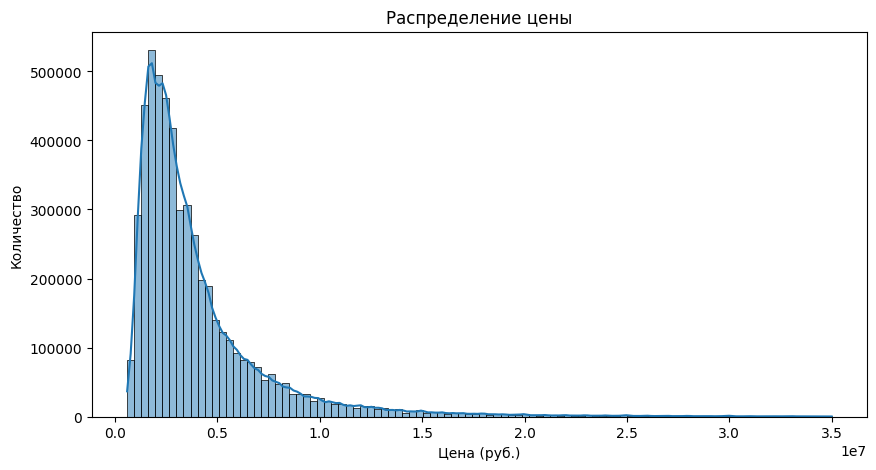

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=100, kde=True)
plt.title('Распределение цены')
plt.xlabel('Цена (руб.)')
plt.ylabel('Количество')
plt.show()

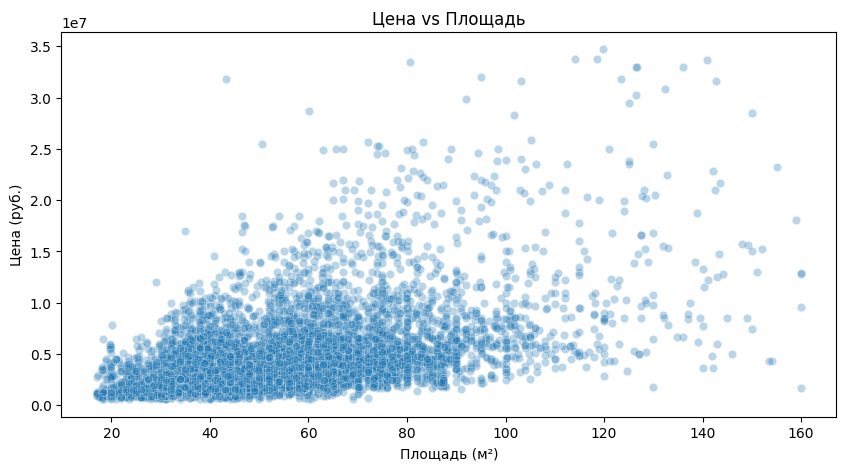

In [36]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df.sample(10000, random_state=42), x='area', y='price', alpha=0.3)
plt.title('Цена vs Площадь')
plt.xlabel('Площадь (м²)')
plt.ylabel('Цена (руб.)')
plt.show()

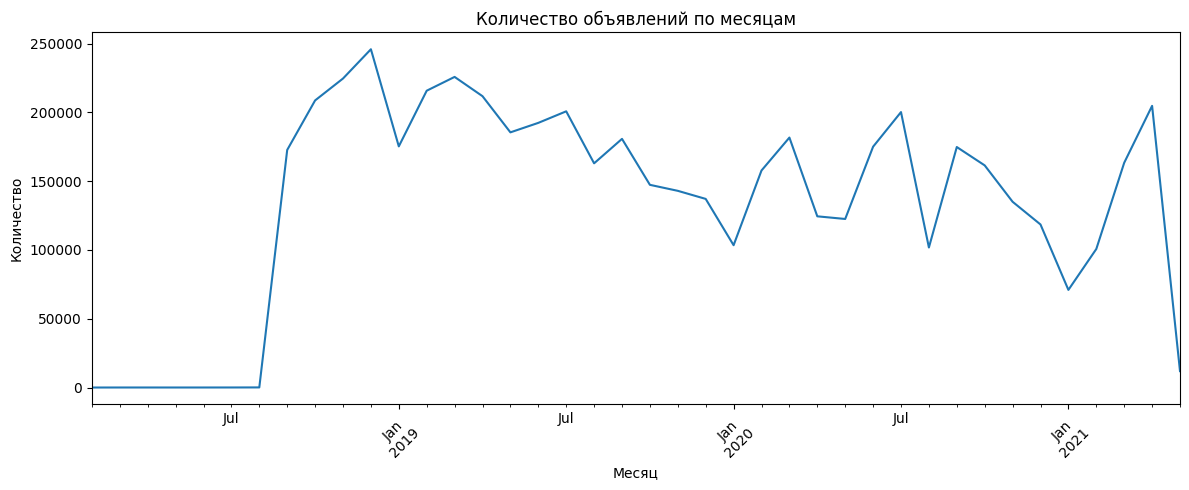

In [37]:
plt.figure(figsize=(12, 5))
df.groupby(df['datetime'].dt.to_period('M')).size().plot()
plt.title('Количество объявлений по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Дополнительная обработка данных (Feature Engineering)

Создание новых признаков на основе существующих данных 
для улучшения качества анализа.

In [38]:
# Из datetime
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek

# Из существующих признаков
df['price_per_m2'] = df['price'] / df['area']
df['floor_ratio'] = df['level'] / df['levels']

In [39]:
df[['price_per_m2', 'floor_ratio', 'year', 'month', 'day_of_week']].describe()

,price_per_m2,floor_ratio,year,month,day_of_week
count,5.338839e+06,5.338839e+06,5.338839e+06,5.338839e+06,5.338839e+06
mean,7.638209e+04,5.670753e-01,2.019376e+03,6.627042e+00,2.642932e+00
std,5.216677e+04,2.895547e-01,8.720819e-01,3.541638e+00,1.897283e+00
min,4.062500e+03,2.702703e-02,2.018000e+03,1.000000e+00,0.000000e+00
25%,4.305556e+04,3.333333e-01,2.019000e+03,3.000000e+00,1.000000e+00
50%,6.089744e+04,5.833333e-01,2.019000e+03,7.000000e+00,3.000000e+00
75%,9.062500e+04,8.000000e-01,2.020000e+03,1.000000e+01,4.000000e+00
max,1.076389e+06,1.000000e+00,2.021000e+03,1.200000e+01,6.000000e+00


In [40]:
df.head()

,price,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type,datetime,year,month,day_of_week,price_per_m2,floor_ratio
0,6050000,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1,2018-02-19 20:00:21,2018,2,0,73244.552058,0.800000
1,8650000,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1,2018-02-27 12:04:54,2018,2,1,125180.897250,0.208333
2,4000000,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1,2018-02-28 15:44:00,2018,2,2,60606.060606,0.555556
3,1850000,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11,2018-03-01 11:24:52,2018,3,3,48684.210526,0.750000
4,5450000,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1,2018-03-01 17:42:43,2018,3,3,90833.333333,0.928571


# Масштабирование, нормализация, кодирование признаков

Я выбрал следующие признаки для дальнейшей работы:
1. geo_lat	
2. geo_lon
3. region
4. building_type
5. rooms
6. area	
7. kitchen_area	
8. object_type	
9. year	
10. month	
11. day_of_week	
16. floor_ratio

Удаляем следующие признаки:
1. price_per_m2 — target leakage
2. datetime — дубликат
3. level, levels — заменены на floor_ratio

In [41]:
df = df.drop(columns=['price_per_m2', 'datetime', 'level', 'levels'])

In [42]:
df

,price,geo_lat,geo_lon,region,building_type,rooms,area,kitchen_area,object_type,year,month,day_of_week,floor_ratio
0,6050000,59.805808,30.376141,2661,1,3,82.6,10.8,1,2018,2,0,0.800000
1,8650000,55.683807,37.297405,81,3,2,69.1,12.0,1,2018,2,1,0.208333
2,4000000,56.295250,44.061637,2871,1,3,66.0,10.0,1,2018,2,2,0.555556
3,1850000,44.996132,39.074783,2843,4,2,38.0,5.0,11,2018,3,3,0.750000
4,5450000,55.918767,37.984642,81,3,2,60.0,10.0,1,2018,3,3,0.928571
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5477001,19739760,55.804736,37.750898,3,1,4,93.2,13.8,11,2021,5,5,0.470588
5477002,12503160,55.841415,37.489624,3,2,2,45.9,6.6,11,2021,5,5,0.531250
5477003,8800000,56.283909,44.075408,2871,2,3,86.5,11.8,1,2021,5,5,0.235294
5477004,11831910,55.804736,37.750898,3,1,2,52.1,18.9,11,2021,5,5,0.242424


# Обучение DecisionTreeRegressor

Датасет содержит в себе более 3.5M строк, что слишком много для DecisionTreeRegressor'a, возьмем небольшой семл 200-300k строк, чтобы модель не переобучилась.

In [62]:
df_decision_tree_regressor = df.sample(n = 200000, random_state=42)

In [66]:
df_decision_tree_regressor

,price,geo_lat,geo_lon,region,building_type,rooms,area,kitchen_area,object_type,year,month,day_of_week,floor_ratio
682154,2150000,44.689362,37.790682,2843,1,1,31.30,7.0,1,2018,12,4,0.800000
2670830,1900000,45.003436,39.083794,2843,0,1,41.30,12.0,11,2019,10,1,0.777778
3297924,3411900,54.749139,20.479168,7896,3,2,66.90,12.3,1,2020,2,1,1.000000
1155116,2250000,54.966119,82.914245,9654,0,3,54.00,6.6,1,2019,2,4,0.500000
2971384,2850000,57.186543,65.621709,3991,3,1,38.00,11.0,1,2019,12,0,0.111111
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4185000,2564000,55.706002,52.351910,2922,2,1,44.00,21.0,11,2020,7,3,0.750000
2368769,1450000,45.020190,38.932573,11416,3,2,40.00,8.0,1,2019,8,5,1.000000
51445,3500000,63.569209,53.658842,4417,3,3,60.00,9.0,1,2018,9,5,0.777778
815586,3483710,56.277279,43.917104,2871,1,2,56.00,9.0,1,2018,12,1,0.588235


In [71]:
X, y = df_decision_tree_regressor.drop(columns = ['price']), df_decision_tree_regressor['price']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [73]:
freq = X_train['region'].value_counts(normalize=True)
freq.index = freq.index.astype(float)
X_train['region'] = X_train['region'].map(freq)
X_test['region'] = X_test['region'].map(freq).fillna(0)
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoder.fit(X_train[['object_type', 'building_type']])
ohe_train = encoder.transform(X_train[['object_type', 'building_type']])
ohe_test = encoder.transform(X_test[['object_type', 'building_type']])
ohe_cols = encoder.get_feature_names_out(['object_type', 'building_type'])
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
ohe_test_df = pd.DataFrame(ohe_test, columns=ohe_cols, index=X_test.index)
X_train = X_train.drop(columns=['object_type', 'building_type'])
X_test = X_test.drop(columns=['object_type', 'building_type'])
X_train = pd.concat([X_train, ohe_train_df], axis=1)
X_test = pd.concat([X_test, ohe_test_df], axis=1)
num_cols = ['geo_lat', 'geo_lon', 'area', 'kitchen_area', 'floor_ratio', 'rooms']
scaler = RobustScaler()
scaler.fit(X_train[num_cols])
robust_train = scaler.transform(X_train[num_cols])
robust_test = scaler.transform(X_test[num_cols])
X_train[num_cols] = robust_train
X_test[num_cols] = robust_test

print(X_train.shape)
print(X_train.head())
print(X_train.isnull().sum())

X_train_small, y_train_small = resample(
    X_train, y_train, 
    n_samples=100_000, 
    random_state=42
)

X_test_small, y_test_small = resample(
    X_test, y_test,
    n_samples=50_000,
    random_state=42
)

# poly = PolynomialFeatures(degree=2)
# X_train_poly = poly.fit_transform(X_train_small)
# X_test_poly = poly.transform(X_test_small)

(134000, 16)
          geo_lat   geo_lon    region  rooms      area  kitchen_area  year  \
4463695 -0.138771  0.445914  0.016284   -1.0 -0.648583     -0.854545  2020   
3899689 -2.779965 -0.141881  0.041560    0.0 -0.247773     -0.672727  2020   
3996879  1.703680 -0.479403  0.082470   -1.0 -0.440891      0.034545  2020   
5350228 -0.328308  0.055048  0.004149    0.0 -0.041296     -0.581818  2021   
4209764 -0.768627  0.219367  0.015060    1.0  0.468826     -0.490909  2020   

         month  day_of_week  floor_ratio  object_type_11  building_type_1  \
4463695      9            0     0.892857             0.0              1.0   
3899689      6            0     0.892857             0.0              0.0   
3996879      7            2    -1.164286             1.0              1.0   
5350228      4            5     0.892857             0.0              1.0   
4209764      8            0    -0.392857             0.0              0.0   

         building_type_2  building_type_3  building_typ

In [77]:
regressor = DecisionTreeRegressor(max_depth=3, random_state=42)

regressor.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [80]:
y_pred = regressor.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'root mean squared error: {rmse}')

root mean squared error: 2398646.7412577425


In [91]:
max_depths = [3,5,7,10,15,None]
RANDOM_STATE = 42
results = []

for depth in max_depths:
    regressor = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    regressor.fit(X_train, y_train)

    y_train_pred = regressor.predict(X_train)
    y_test_pred =regressor.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        'max_depth': depth if depth is not None else 'None',
        'train_rmse': root_mean_squared_error(y_train, y_train_pred),
        'test_rmse' : root_mean_squared_error(y_test, y_test_pred),
        'train_r2'  : r2_score(y_train, y_train_pred),
        'test_r2'   : r2_score(y_test, y_test_pred)
    })

df_results = pd.DataFrame(results)
    

In [92]:
df_results

,max_depth,train_rmse,test_rmse,train_r2,test_r2
0,3,2.373119e+06,2.398647e+06,0.544635,0.546226
1,5,1.985719e+06,1.998232e+06,0.681172,0.685081
2,7,1.694557e+06,1.726775e+06,0.767816,0.764832
3,10,1.412086e+06,1.534873e+06,0.838771,0.814197
4,15,9.228459e+05,1.598688e+06,0.931138,0.798426
5,None,4.311699e+03,1.769759e+06,0.999998,0.752978


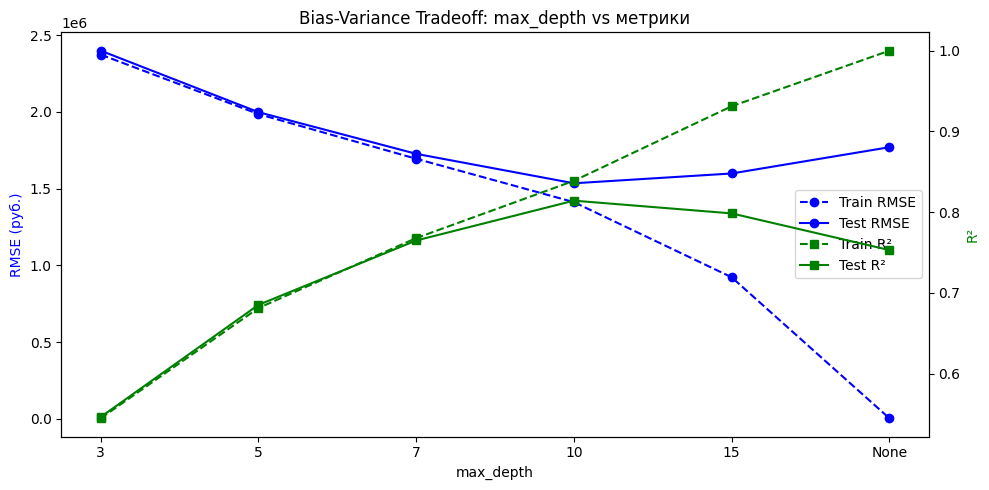

In [93]:
fig, ax1 = plt.subplots(figsize=(10, 5))
x = range(len(df_results))

ax1.plot(x, df_results['train_rmse'], 'b--o', label='Train RMSE')
ax1.plot(x, df_results['test_rmse'],  'b-o',  label='Test RMSE')
ax1.set_ylabel("RMSE (руб.)", color='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(df_results['max_depth'])
ax1.set_xlabel("max_depth")

ax2 = ax1.twinx()
ax2.plot(x, df_results['train_r2'], 'g--s', label='Train R²')
ax2.plot(x, df_results['test_r2'],  'g-s',  label='Test R²')
ax2.set_ylabel("R²", color='green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title("Bias-Variance Tradeoff: max_depth vs метрики")
plt.tight_layout()
plt.show()

Оптимальный max_depth ≈ 10 — баланс между bias и variance
При depth=None модель memorizes train данные, теряя способность к обобщению
Лучший Test R² ≈ 0.82 — не так плохо, как при глубинах 3 и 4

# RandomForestRegressor

In [104]:
features = X_train.columns.tolist()

In [99]:
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

print(f"Train RMSE: {root_mean_squared_error(y_train, y_train_pred):,.0f} руб.")
print(f"Test  RMSE: {root_mean_squared_error(y_test, y_test_pred):,.0f} руб.")
print(f"Train R²:   {r2_score(y_train, y_train_pred):.4f}")
print(f"Test  R²:   {r2_score(y_test, y_test_pred):.4f}")

Train RMSE: 1,418,212 руб.
Test  RMSE: 1,496,901 руб.
Train R²:   0.8374
Test  R²:   0.8233


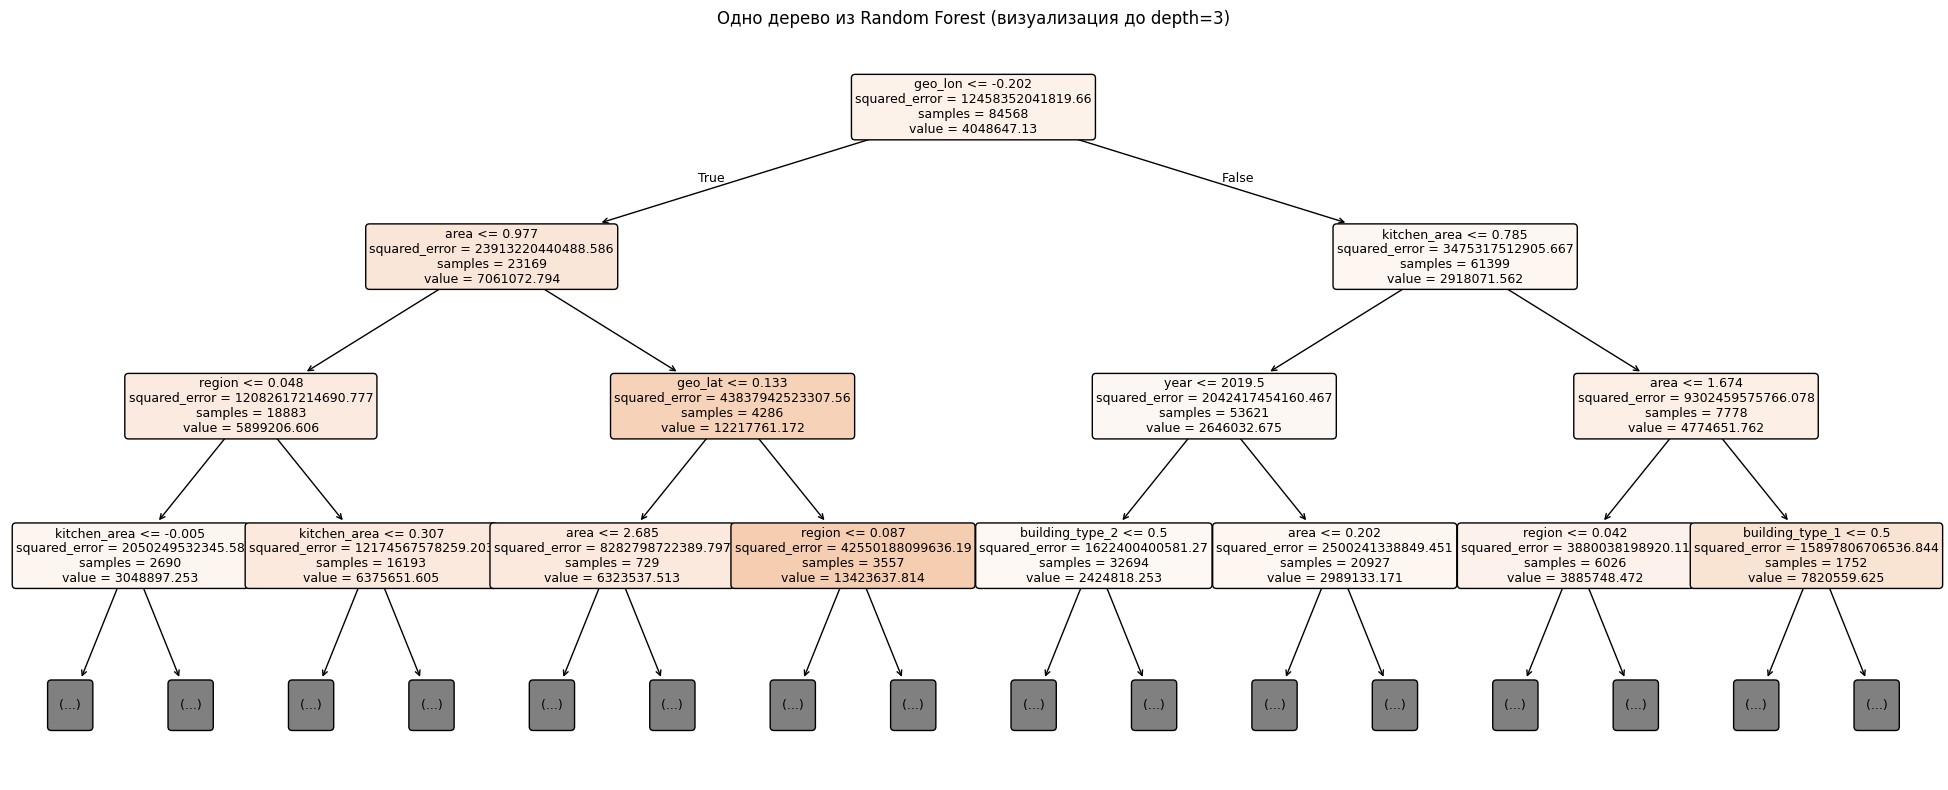

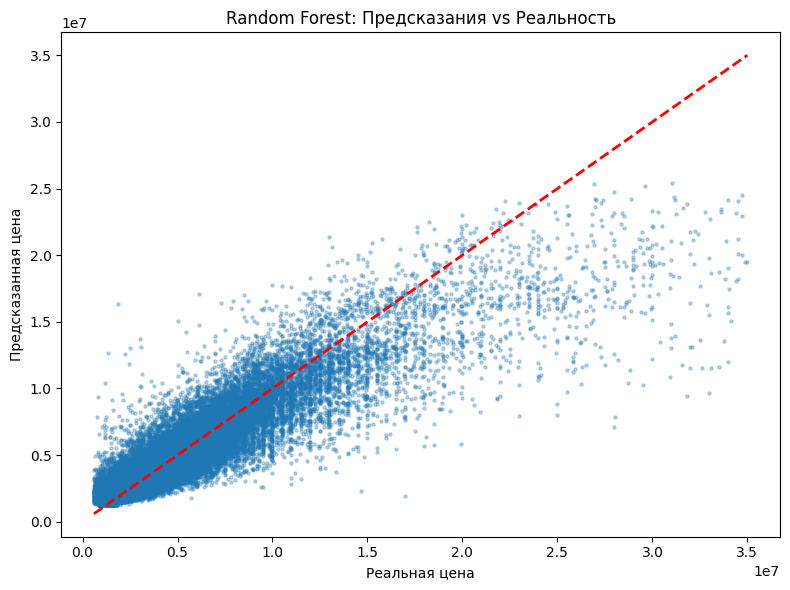

In [105]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(rf.estimators_[0], feature_names=features,
          filled=True, rounded=True, fontsize=9, ax=ax,
          max_depth=3)  # ограничиваем для читаемости
plt.title("Одно дерево из Random Forest (визуализация до depth=3)")
plt.tight_layout()
plt.show()

# Scatter plot: предсказания vs реальные значения
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_test_pred, alpha=0.3, s=5)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel("Реальная цена")
ax.set_ylabel("Предсказанная цена")
ax.set_title("Random Forest: Предсказания vs Реальность")
plt.tight_layout()
plt.show()

In [112]:
n_estimators_list = [10, 20, 50, 100]
max_features_list = ['sqrt', 'log2', 1.0]

In [115]:
results = []

for estimators in n_estimators_list:
    for feature in max_features_list:
        rf = RandomForestRegressor(n_estimators=estimators, max_features=feature)
        rf.fit(X_train, y_train)

        # Метрики на train
        y_train_pred = rf.predict(X_train)
        train_rmse = root_mean_squared_error(y_train, y_train_pred)
        train_r2 = r2_score(y_train, y_train_pred)

        # Метрики на test
        y_test_pred = rf.predict(X_test)
        test_rmse = root_mean_squared_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)

        results.append({
            'n_estimators': estimators,
            'max_features': feature,
            'train_rmse': train_rmse,
            'train_r2': train_r2,
            'test_rmse': test_rmse,
            'test_r2': test_r2,
        })

In [116]:
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 n_estimators max_features    train_rmse  train_r2    test_rmse  test_r2
           10         sqrt 569225.188584  0.973801 1.315937e+06 0.863423
           10         log2 578590.127160  0.972932 1.315650e+06 0.863483
           10          1.0 552831.172644  0.975288 1.276493e+06 0.871488
           20         sqrt 513207.356234  0.978704 1.266587e+06 0.873475
           20         log2 520626.313611  0.978083 1.272332e+06 0.872324
           20          1.0 498691.735084  0.979891 1.238731e+06 0.878979
           50         sqrt 479434.636645  0.981414 1.238294e+06 0.879064
           50         log2 478751.266283  0.981467 1.240702e+06 0.878594
           50          1.0 468349.474877  0.982264 1.218052e+06 0.882986
          100         sqrt 468601.781064  0.982245 1.230365e+06 0.880608
          100         log2 466372.637486  0.982413 1.230410e+06 0.880599
          100          1.0 460856.366153  0.982827 1.209413e+06 0.884640


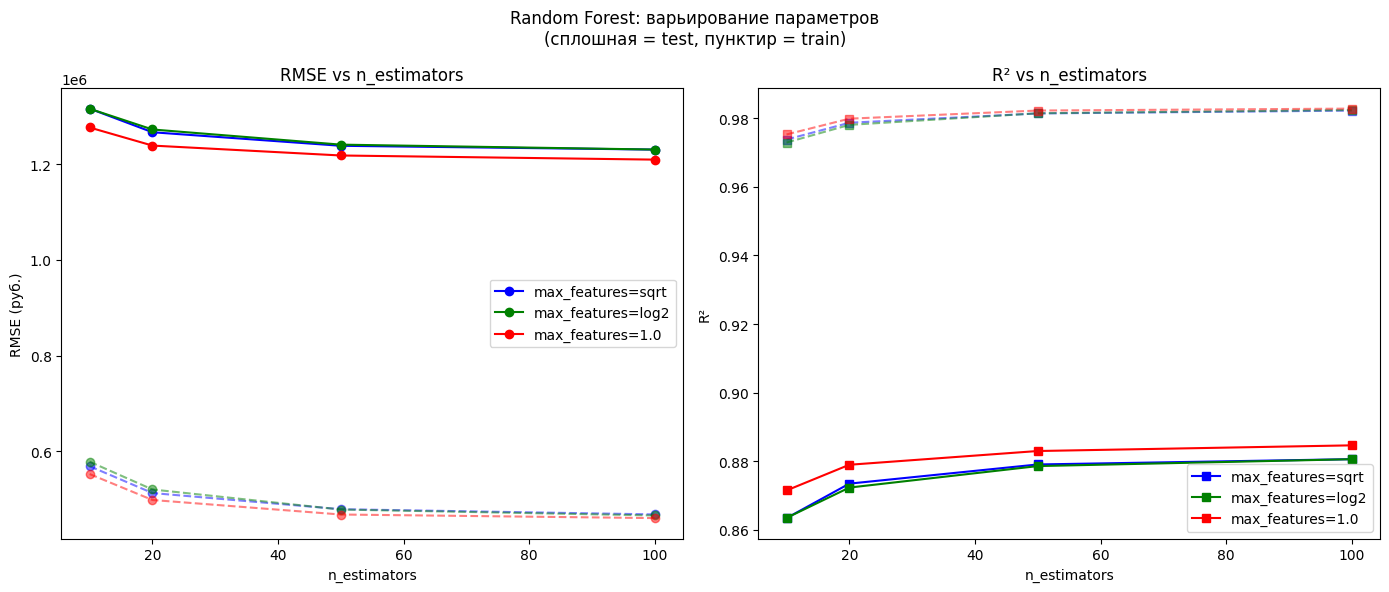

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'sqrt': 'blue', 'log2': 'green', 1.0: 'red'}

for max_feat in max_features_list:
    subset = df_results[df_results['max_features'] == max_feat]
    
    axes[0].plot(subset['n_estimators'], subset['test_rmse'],
                 marker='o', color=colors[max_feat], label=f'max_features={max_feat}')
    axes[0].plot(subset['n_estimators'], subset['train_rmse'],
                 marker='o', color=colors[max_feat], linestyle='--', alpha=0.5)

axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('RMSE (руб.)')
axes[0].set_title('RMSE vs n_estimators')
axes[0].legend()

for max_feat in max_features_list:
    subset = df_results[df_results['max_features'] == max_feat]
    
    axes[1].plot(subset['n_estimators'], subset['test_r2'],
                 marker='s', color=colors[max_feat], label=f'max_features={max_feat}')
    axes[1].plot(subset['n_estimators'], subset['train_r2'],
                 marker='s', color=colors[max_feat], linestyle='--', alpha=0.5)

axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('R²')
axes[1].set_title('R² vs n_estimators')
axes[1].legend()

plt.suptitle('Random Forest: варьирование параметров\n(сплошная = test, пунктир = train)')
plt.tight_layout()
plt.show()

# Вывод 

В данной работе помимо стандартной предобработки и рабоыт с данными было построено регрессионное дерево решений, изучены разные глубины деревьев, и как они влияют на точность модели. Как влияет отсутствие максимальной глубины на модель. (Модель делается глубокой до бесконечности, что приводит к переобучению модели). Также было изучено варьирование параметов и их влияние на результат обучения RandomForestRegressor.


При обучении лучший DecissionTree при max_depth = 10 rmse = 1.412086e+06	r2_score = 0.838771, результат неплохой для стандартнйо модели, учитывая то, что данные таргета не нормированы, но вполне удовлетворительны.  Из графика видно что точки в целом следуют красной линии — модель улавливает общий тренд. В низком ценовом диапазоне точность модели достаточно высокая. Ошибка 0-0.5 млн рублей. При высоких ценах модель часто занижает — точки уходят ниже красной линии, реальные цены оказываются больше, чем предполагает модель. RF усредняет предсказания деревьев, что сглаживает экстремальные значения.


Для улучшения полученных результатов также была опробована модель RandomForestRegressor - беггинг над деревьями решений, лучший результат получился при   n_estimators = 100 max_features = 1.0 test_r2 = 0.884640. В отличии от Decission Tree модель обладает хорошей обощающей способностью, что на "малых" значениях, так и на "больших".

Анализ графиков варьирования параметров показал, что RMSE убывает с ростом n_estimators, однако после 50 деревьев наблюдается эффект diminishing returns. Параметр max_features=1.0 стабильно давал лучший результат, что объясняется малым числом признаков (16) — ограничение до sqrt было бы слишком агрессивным.